# Análisis Exploratorio del Dataset de Diabetes

Este notebook realiza un análisis completo del dataset de progresión de diabetes de scikit-learn, incluyendo:
- Carga y exploración de datos
- Estadísticas descriptivas
- Visualización de distribuciones
- Análisis de correlaciones
- Balance de clases para clasificación

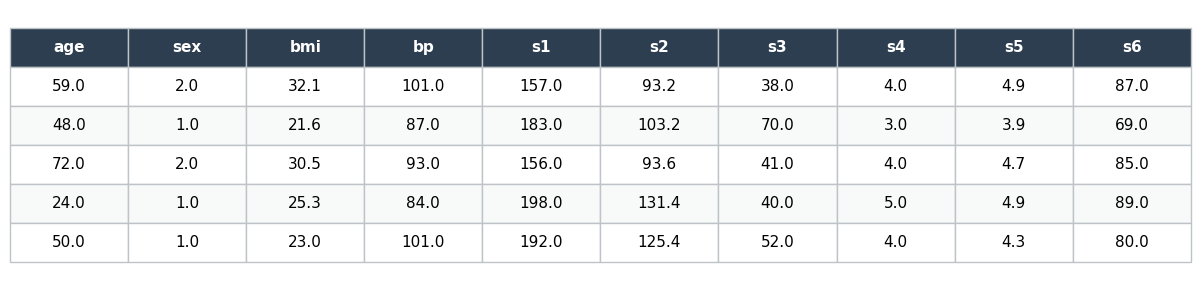

✓ Tabla guardada como 'tabla_diabetes.png'


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt

# Cargar dataset completo
data = load_diabetes(scaled=False)
X_raw = data.data
X = X_raw                  # alias usado en celdas posteriores
y = data.target            # target continuo
feature_names = data.feature_names

# DataFrame completo con target (necesario para correlaciones y resumen)
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

# --- Tabla visual: primeras 5 filas ---
df_head = df[list(feature_names)].head(5).round(1)

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis("off")
tabla_visual = ax.table(
    cellText=df_head.values,
    colLabels=df_head.columns,
    cellLoc="center",
    loc="center"
)
tabla_visual.auto_set_font_size(False)
tabla_visual.set_fontsize(11)
tabla_visual.scale(1.2, 2.0)

for (row, col), cell in tabla_visual.get_celld().items():
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#2C3E50")
    else:
        cell.set_facecolor("#F8F9F9" if row % 2 == 0 else "#FFFFFF")
    cell.set_edgecolor("#BDC3C7")

plt.tight_layout()
nombre_imagen = "tabla_diabetes.png"
plt.savefig(nombre_imagen, dpi=300, bbox_inches="tight")
plt.show()
print(f"✓ Tabla guardada como '{nombre_imagen}'")


## 1. Información General del Dataset

In [2]:
# Crear DataFrame para visualización
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print("\n" + "="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)
print(f"\nForma del dataset: {df.shape}")
print(f"  • Muestras (pacientes): {df.shape[0]}")
print(f"  • Características: {df.shape[1]}")
print(f"  • Variable objetivo: 1 (progresión a 1 año)")

print("\nNombres de características:")
for i, name in enumerate(feature_names, 1):
    print(f"  {i}. {name}")

print("\nTipos de datos:")
print(df.dtypes)

print("\nMissingValues (valores nulos):")
print(df.isnull().sum())
print("\n✓ No hay valores nulos en el dataset")


INFORMACIÓN DEL DATASET

Forma del dataset: (442, 11)
  • Muestras (pacientes): 442
  • Características: 11
  • Variable objetivo: 1 (progresión a 1 año)

Nombres de características:
  1. age
  2. sex
  3. bmi
  4. bp
  5. s1
  6. s2
  7. s3
  8. s4
  9. s5
  10. s6

Tipos de datos:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object

MissingValues (valores nulos):
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

✓ No hay valores nulos en el dataset


## 2. Estadísticas Descriptivas

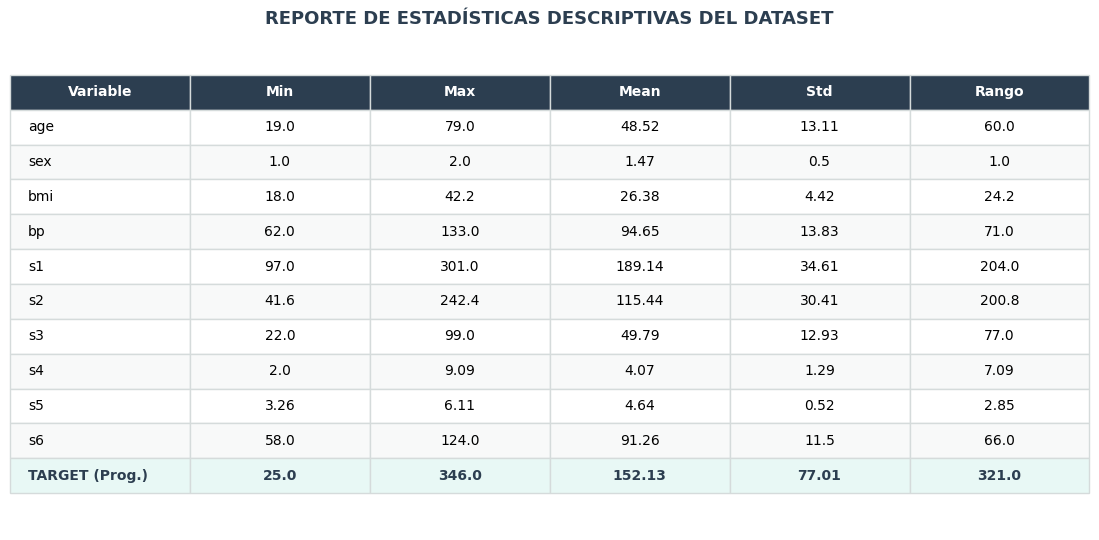

✓ ¡Estadísticas unificadas y guardadas como 'estadisticas_diabetes.png' en alta definición!


In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt

# 1. Cargar el dataset original completo para el cálculo real
data = load_diabetes(scaled=False)
X_raw = data.data
y = data.target
feature_names = data.feature_names

# Crear DataFrame con todas las características
df_completo = pd.DataFrame(X_raw, columns=feature_names)

# 2. Calcular estadísticas descriptivas de las características
stats_features = df_completo.describe().T
stats_features['rango'] = stats_features['max'] - stats_features['min']
stats_features = stats_features[['min', 'max', 'mean', 'std', 'rango']]

# 3. Calcular estadísticas del Target y prepararlo con el mismo formato
stats_target = pd.DataFrame({
    'min': [y.min()],
    'max': [y.max()],
    'mean': [y.mean()],
    'std': [y.std()],
    'rango': [y.max() - y.min()]
}, index=['TARGET (Prog.)'])

# Unificar todo en una sola tabla de estadísticas
tabla_final = pd.concat([stats_features, stats_target]).round(2)
tabla_final.index.name = 'Variable'
tabla_final = tabla_final.reset_index()

# 4. Diseñar la visualización con Matplotlib
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis('off')

# Renderizar la tabla
tabla_visual = ax.table(
    cellText=tabla_final.values,
    colLabels=[c.capitalize() for c in tabla_final.columns],
    cellLoc='center',
    loc='center'
)

# 5. Estilizar la tabla (Colores corporativos y espaciados)
tabla_visual.auto_set_font_size(False)
tabla_visual.set_fontsize(10)
tabla_visual.scale(1.2, 1.8)  # Alto de fila cómodo para lectura

# Aplicar estilos fila por fila
for (row, col), cell in tabla_visual.get_celld().items():
    if row == 0:
        # Cabecera principal
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2C3E50')  # Azul oscuro elegante
    else:
        # Resaltar la última fila (el Target) de manera especial
        if row == len(tabla_final):
            cell.set_text_props(weight='bold', color='#2C3E50')
            cell.set_facecolor('#E8F8F5')  # Fondo verde menta suave para el Target
        # Efecto cebra para el resto de características
        elif row % 2 == 0:
            cell.set_facecolor('#F8F9F9')
        else:
            cell.set_facecolor('#FFFFFF')
            
        # Alinear a la izquierda los nombres de las variables para mejor orden
        if col == 0:
            cell.set_text_props(ha='left')
            
    cell.set_edgecolor('#D5DBDB')  # Bordes sutiles

# Título del reporte integrado en la imagen
plt.title("REPORTE DE ESTADÍSTICAS DESCRIPTIVAS DEL DATASET", 
          fontsize=13, weight='bold', color='#2C3E50', pad=10)

plt.tight_layout()

# 6. Guardar el reporte estadístico
nombre_imagen = "estadisticas_diabetes.png"
plt.savefig(nombre_imagen, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ¡Estadísticas unificadas y guardadas como '{nombre_imagen}' en alta definición!")

In [4]:
print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS - CARACTERÍSTICAS")
print("="*60)

stats_df = df.describe().T
stats_df['rango'] = stats_df['max'] - stats_df['min']
print("\n", stats_df[['min', 'max', 'mean', 'std', 'rango']])

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS - TARGET (Progresión)")
print("="*60)

print(f"\nVariable objetivo (progresión a 1 año):")
print(f"  • Mínimo: {y.min():.2f}")
print(f"  • Máximo: {y.max():.2f}")
print(f"  • Media: {y.mean():.2f}")
print(f"  • Mediana: {np.median(y):.2f}")
print(f"  • Desv. Est.: {y.std():.2f}")
print(f"  • Rango Intercuartil (Q1-Q3): {np.percentile(y, 25):.2f} - {np.percentile(y, 75):.2f}")


ESTADÍSTICAS DESCRIPTIVAS - CARACTERÍSTICAS

             min      max        mean        std     rango
age     19.0000   79.000   48.518100  13.109028   60.0000
sex      1.0000    2.000    1.468326   0.499561    1.0000
bmi     18.0000   42.200   26.375792   4.418122   24.2000
bp      62.0000  133.000   94.647014  13.831283   71.0000
s1      97.0000  301.000  189.140271  34.608052  204.0000
s2      41.6000  242.400  115.439140  30.413081  200.8000
s3      22.0000   99.000   49.788462  12.934202   77.0000
s4       2.0000    9.090    4.070249   1.290450    7.0900
s5       3.2581    6.107    4.641411   0.522391    2.8489
s6      58.0000  124.000   91.260181  11.496335   66.0000
target  25.0000  346.000  152.133484  77.093005  321.0000

ESTADÍSTICAS DESCRIPTIVAS - TARGET (Progresión)

Variable objetivo (progresión a 1 año):
  • Mínimo: 25.00
  • Máximo: 346.00
  • Media: 152.13
  • Mediana: 140.50
  • Desv. Est.: 77.01
  • Rango Intercuartil (Q1-Q3): 87.00 - 211.50


## 3. Distribución del Target (Progresión Continua)

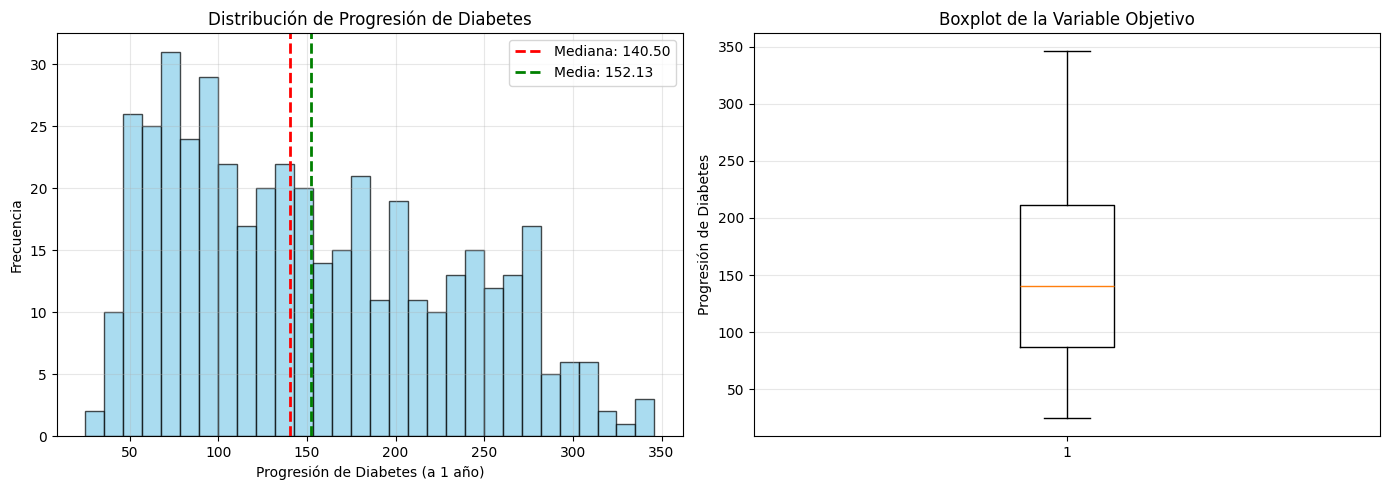


✓ La distribución del target es aproximadamente normal


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del target
axes[0].hist(y, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.median(y), color='red', linestyle='--', linewidth=2, label=f'Mediana: {np.median(y):.2f}')
axes[0].axvline(y.mean(), color='green', linestyle='--', linewidth=2, label=f'Media: {y.mean():.2f}')
axes[0].set_xlabel('Progresión de Diabetes (a 1 año)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Progresión de Diabetes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot del target
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Progresión de Diabetes')
axes[1].set_title('Boxplot de la Variable Objetivo')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ La distribución del target es aproximadamente normal")

## 4. Binarización del Target (para clasificación)

In [6]:
median_val = np.median(y)
y_binary = (y > median_val).astype(int)

# Mapeo de clases
class_0 = np.sum(y_binary == 0)
class_1 = np.sum(y_binary == 1)

print("\n" + "="*60)
print("BINARIZACIÓN DEL TARGET")
print("="*60)

print(f"\nUmbral de binarización (mediana): {median_val:.2f}")
print(f"\nClase 0 - Diabetes CONTROLADA (progresión ≤ {median_val:.2f}):")
print(f"  • Cantidad: {class_0} pacientes")
print(f"  • Porcentaje: {100*class_0/len(y_binary):.1f}%")

print(f"\nClase 1 - Diabetes DESCONTROLADA (progresión > {median_val:.2f}):")
print(f"  • Cantidad: {class_1} pacientes")
print(f"  • Porcentaje: {100*class_1/len(y_binary):.1f}%")

print(f"\nBalance de clases: {'✓ Perfectamente balanceado' if class_0 == class_1 else 'Desbalanceado'}")


BINARIZACIÓN DEL TARGET

Umbral de binarización (mediana): 140.50

Clase 0 - Diabetes CONTROLADA (progresión ≤ 140.50):
  • Cantidad: 221 pacientes
  • Porcentaje: 50.0%

Clase 1 - Diabetes DESCONTROLADA (progresión > 140.50):
  • Cantidad: 221 pacientes
  • Porcentaje: 50.0%

Balance de clases: ✓ Perfectamente balanceado


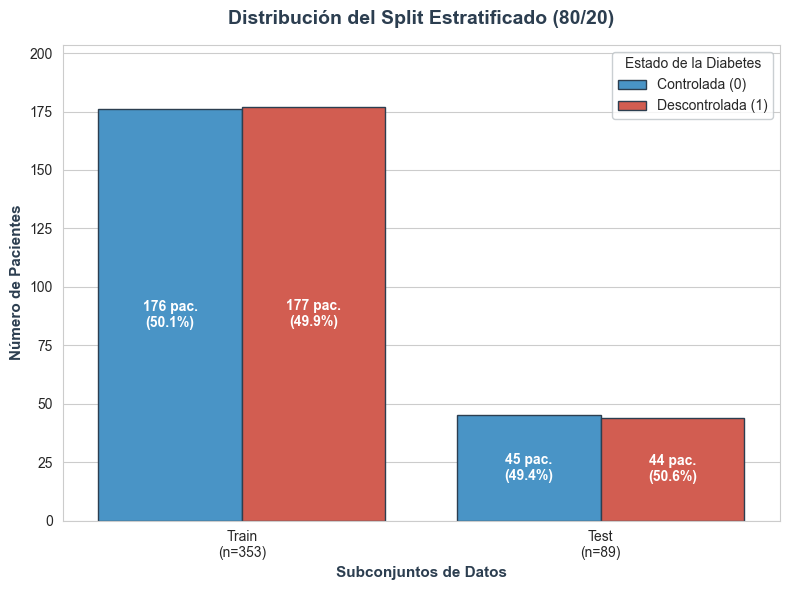

✓ ¡Gráfica de distribución generada con éxito y guardada como 'split_estratificado.png'!


In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar datos y binarizar el target (siguiendo tu lógica original)
data = load_diabetes(scaled=False)
X = data.data
y_continuous = data.target

median_val = np.median(y_continuous)
y_binary = (y_continuous > median_val).astype(int)

# 2. Hacer el Split Estratificado (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

# 3. Calcular las frecuencias y porcentajes para el reporte y la gráfica
def obtener_metricas_clase(y_arr, nombre_split):
    total = len(y_arr)
    c0 = np.sum(y_arr == 0)
    c1 = np.sum(y_arr == 1)
    return [
        {"Split": nombre_split, "Clase": "Controlada (0)", "Cantidad": c0, "Porcentaje": (c0/total)*100},
        {"Split": nombre_split, "Clase": "Descontrolada (1)", "Cantidad": c1, "Porcentaje": (c1/total)*100}
    ]

# Crear un DataFrame estructurado con los datos de los splits
datos_splits = obtener_metricas_clase(y_train, f"Train\n(n={len(y_train)})") + \
               obtener_metricas_clase(y_test, f"Test\n(n={len(y_test)})")
df_plot = pd.DataFrame(datos_splits)

# --- CONFIGURACIÓN DE LA GRÁFICA ---
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar gráfico de barras agrupadas por Split y Clase
colors = ["#3498DB", "#E74C3C"] # Azul para controlado, Rojo para descontrolado
sns.barplot(data=df_plot, x="Split", y="Cantidad", hue="Clase", palette=colors, ax=ax, edgecolor="#2C3E50", lw=1)

# Agregar etiquetas de texto con los Números y Porcentajes dentro/sobre las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # Evitar etiquetas en barras vacías
        # Encontrar el porcentaje correspondiente en nuestro DataFrame
        es_test = p.get_x() > 0.5
        es_descontrolada = p.get_x() % 1 > 0.2  # Ajuste de posición de la barra hue
        
        # Filtrar fila correcta para extraer el porcentaje exacto
        split_buscado = "Test" if es_test else "Train"
        clase_buscada = "Descontrolada (1)" if es_descontrolada else "Controlada (0)"
        
        row = df_plot[(df_plot['Split'].str.contains(split_buscado)) & (df_plot['Clase'] == clase_buscada)].iloc[0]
        porcentaje = row['Porcentaje']
        
        # Colocar el texto formateado
        ax.annotate(f"{int(height)} pac.\n({porcentaje:.1f}%)",
                    (p.get_x() + p.get_width() / 2., height / 2), # Centrado a la mitad de la barra
                    ha='center', va='center',
                    xytext=(0, 0),
                    textcoords='offset points',
                    color='white', weight='bold', fontsize=10)

# Estilizar el contenedor de la gráfica
plt.title("Distribución del Split Estratificado (80/20)", fontsize=14, weight='bold', pad=15, color='#2C3E50')
plt.xlabel("Subconjuntos de Datos", fontsize=11, weight='bold', color='#2C3E50')
plt.ylabel("Número de Pacientes", fontsize=11, weight='bold', color='#2C3E50')
plt.ylim(0, df_plot['Cantidad'].max() * 1.15) # Espacio arriba para que respire la gráfica
plt.legend(title="Estado de la Diabetes", frameon=True, facecolor='white', edgecolor='#BDC3C7')

plt.tight_layout()

# Guardar la imagen en alta definición
nombre_grafica = "split_estratificado.png"
plt.savefig(nombre_grafica, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ¡Gráfica de distribución generada con éxito y guardada como '{nombre_grafica}'!")

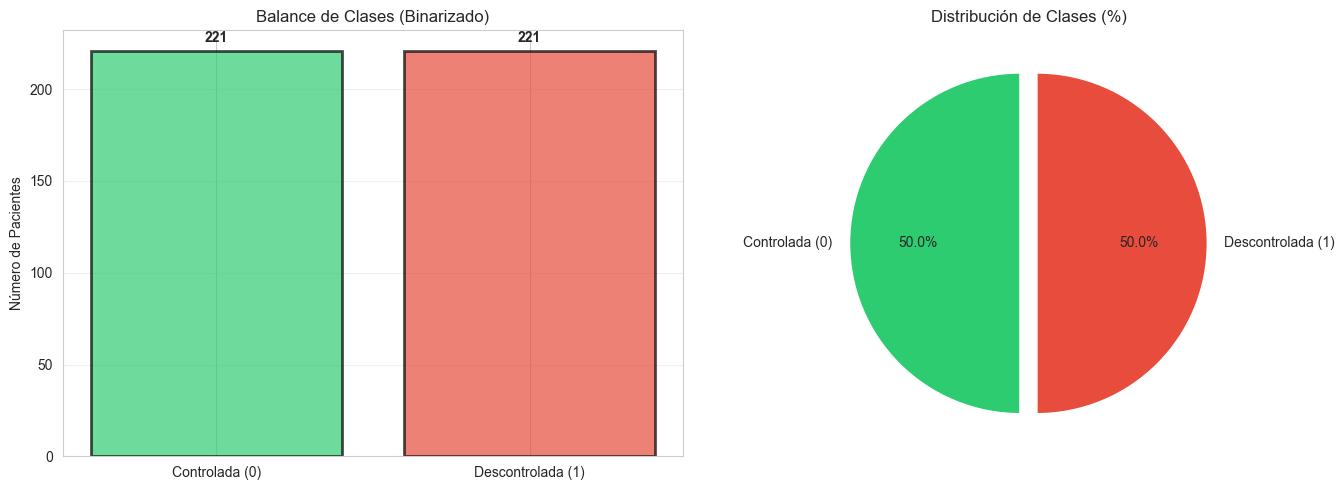

In [8]:
# Visualizar balance de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
clases = ['Controlada (0)', 'Descontrolada (1)']
valores = [class_0, class_1]
colores = ['#2ecc71', '#e74c3c']

axes[0].bar(clases, valores, color=colores, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Número de Pacientes')
axes[0].set_title('Balance de Clases (Binarizado)')
axes[0].grid(alpha=0.3, axis='y')

# Añadir valores sobre las barras
for i, v in enumerate(valores):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Gráfico circular (pie chart)
axes[1].pie(valores, labels=clases, colors=colores, autopct='%1.1f%%', 
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Distribución de Clases (%)')

plt.tight_layout()
plt.show()

## 5. Correlación de Características con el Target


CORRELACIÓN DE CARACTERÍSTICAS CON TARGET (Pearson)
bmi      → +0.5865  (FUERTE   - ↑)
s5       → +0.5659  (FUERTE   - ↑)
bp       → +0.4415  (MODERADA - ↑)
s4       → +0.4305  (MODERADA - ↑)
s3       → -0.3948  (MODERADA - ↓)
s6       → +0.3825  (MODERADA - ↑)
s1       → +0.2120  (DÉBIL    - ↑)
age      → +0.1879  (DÉBIL    - ↑)
s2       → +0.1741  (DÉBIL    - ↑)
sex      → +0.0431  (DÉBIL    - ↑)


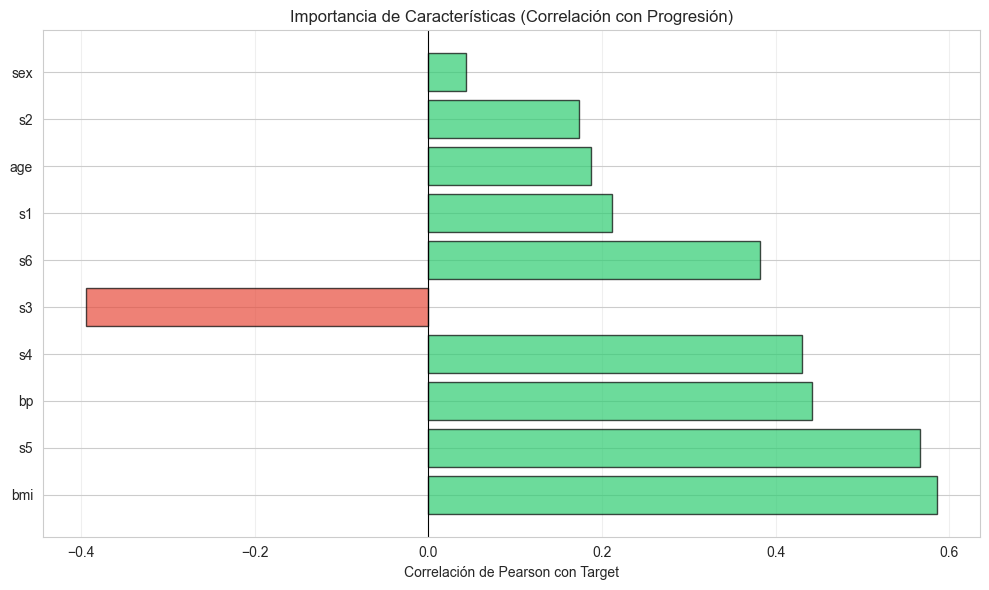

In [9]:
# Calcular correlaciones con el target continuo
correlations = []
for i, name in enumerate(feature_names):
    corr = np.corrcoef(X[:, i], y)[0, 1]
    correlations.append((name, corr))

# Ordenar por valor absoluto de correlación
correlations_sorted = sorted(correlations, key=lambda x: abs(x[1]), reverse=True)

print("\n" + "="*60)
print("CORRELACIÓN DE CARACTERÍSTICAS CON TARGET (Pearson)")
print("="*60)

for name, corr in correlations_sorted:
    direction = "↑" if corr > 0 else "↓"
    strength = "FUERTE" if abs(corr) > 0.5 else "MODERADA" if abs(corr) > 0.3 else "DÉBIL"
    print(f"{name:8} → {corr:+.4f}  ({strength:8} - {direction})")

# Visualizar correlaciones
fig, ax = plt.subplots(figsize=(10, 6))

names = [x[0] for x in correlations_sorted]
corrs = [x[1] for x in correlations_sorted]
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in corrs]

bars = ax.barh(names, corrs, color=colors, alpha=0.7, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con Target')
ax.set_title('Importancia de Características (Correlación con Progresión)')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 6. Matriz de Correlación

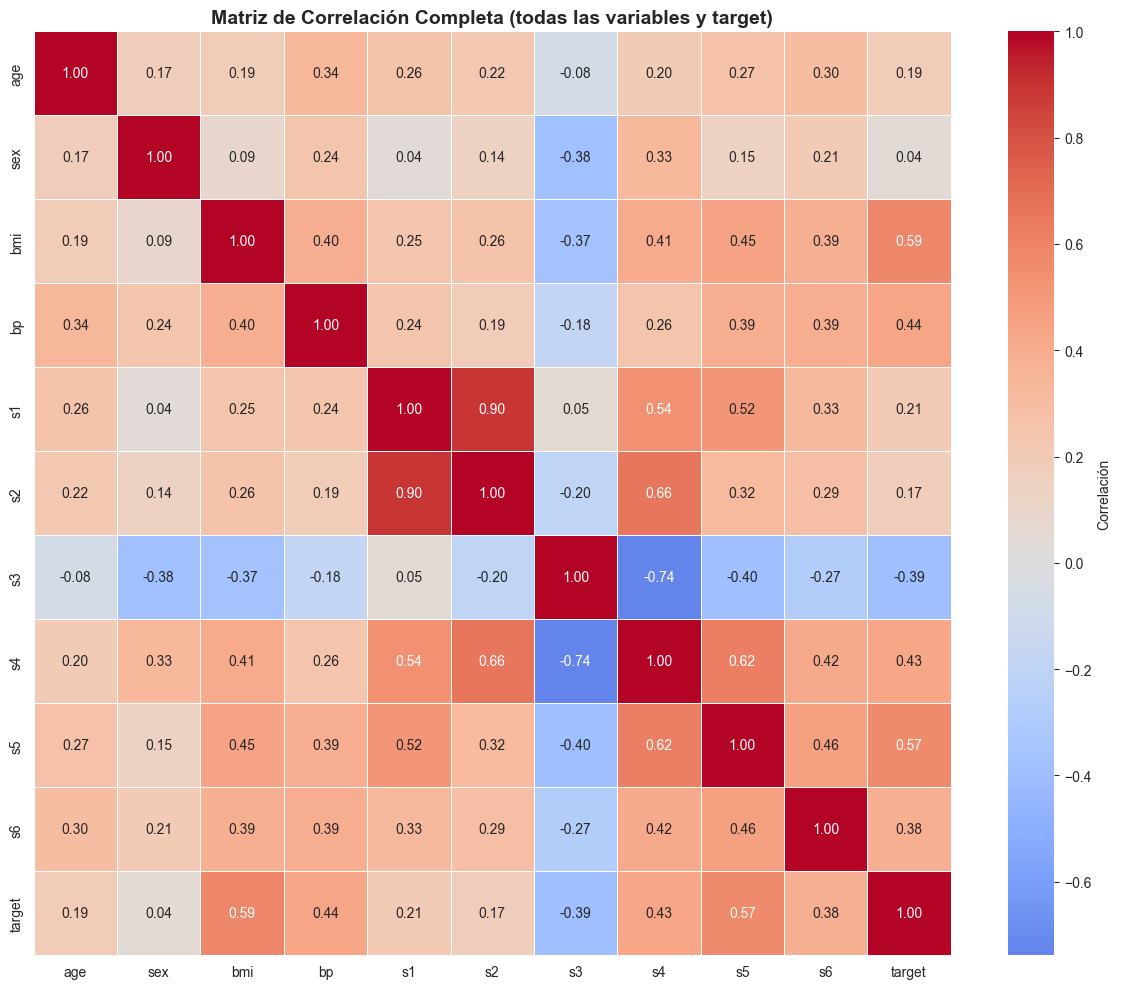


✓ Visualización de correlaciones completada


In [10]:
# Crear matriz de correlación
correlation_matrix = df.corr()

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlación'}, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación Completa (todas las variables y target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Visualización de correlaciones completada")

## 7. Análisis Individual por Característica

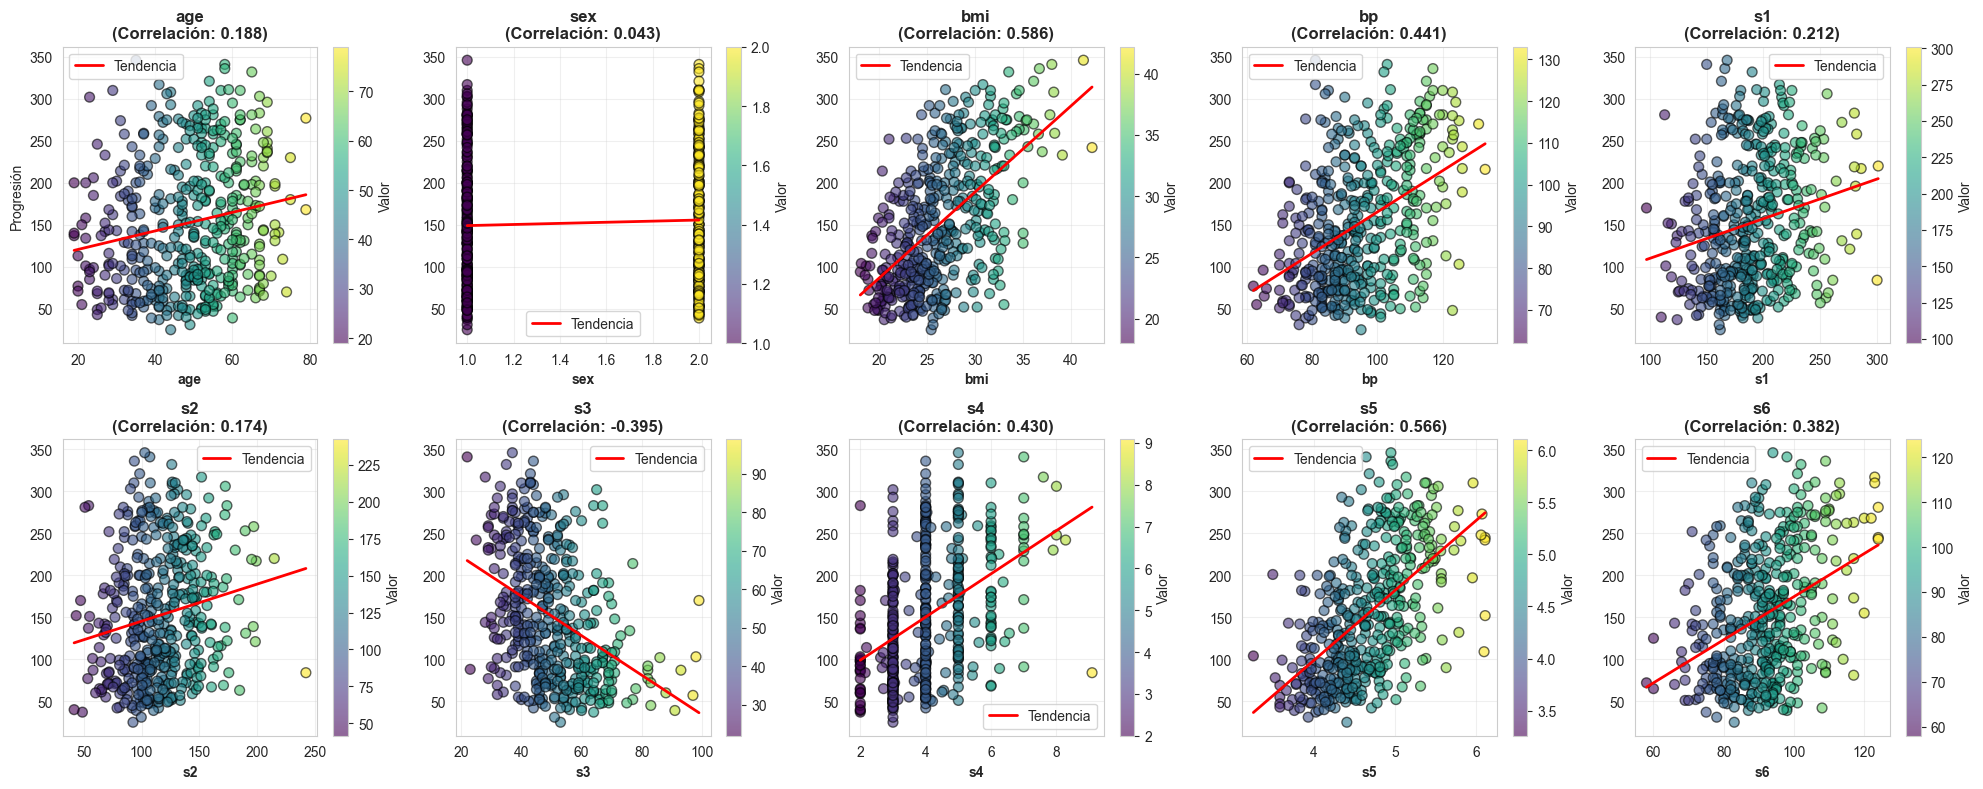


✓ Gráficos de dispersión por característica completados


In [11]:
# Crear visualizaciones de cada característica vs target
n_features = len(feature_names)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 8))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    ax = axes[i]
    scatter = ax.scatter(X[:, i], y, alpha=0.6, c=X[:, i], cmap="viridis", edgecolors="black", s=50)
    z = np.polyfit(X[:, i], y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(X[:, i].min(), X[:, i].max(), 100)
    ax.plot(x_line, p(x_line), "r-", linewidth=2, label="Tendencia")
    corr = np.corrcoef(X[:, i], y)[0, 1]
    ax.set_xlabel(name, fontweight="bold")
    ax.set_ylabel("Progresión" if i == 0 else "")
    ax.set_title(f"{name}\n(Correlación: {corr:.3f})", fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.colorbar(scatter, ax=ax, label="Valor")

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
print("\n\u2713 Gráficos de dispersión por característica completados")


## 8. Resumen y Conclusiones

C:\Users\sergi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


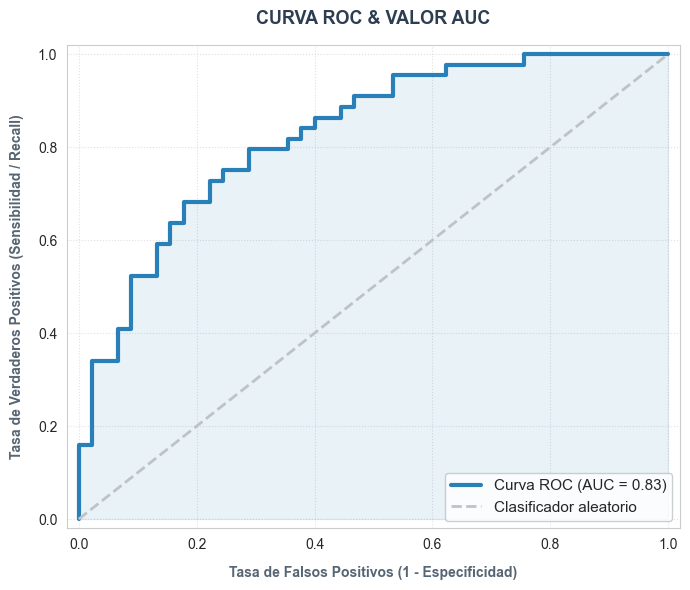

AUC real del modelo: 0.8263
Curva ROC guardada como curva_roc_auc.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

# Reproducir exactamente el mismo pipeline que train_model.py
np.random.seed(42)
data = load_diabetes(scaled=False)
X_raw = data.data.copy()
X_raw[:, 1] = X_raw[:, 1] - 1  # sex: 1/2 -> 0/1
y_binary = (data.target > np.median(data.target)).astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

model = LogisticRegression(penalty="l2", C=1.0, random_state=42, solver="lbfgs")
model.fit(X_train, y_train)

# Probabilidades reales del modelo sobre el conjunto de test
y_score = model.predict_proba(X_test)[:, 1]

# Calcular curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

# Visualizacion
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#2980B9", lw=3, label=f"Curva ROC (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="#BDC3C7", lw=2, linestyle="--", label="Clasificador aleatorio")
plt.fill_between(fpr, tpr, alpha=0.1, color="#2980B9")

plt.title("CURVA ROC & VALOR AUC", fontsize=13, weight="bold", color="#2C3E50", pad=15)
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)", fontsize=10, weight="bold", color="#566573", labelpad=10)
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad / Recall)", fontsize=10, weight="bold", color="#566573", labelpad=10)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="#BDC3C7", fontsize=11)
plt.tight_layout()

nombre_imagen = "curva_roc_auc.png"
plt.savefig(nombre_imagen, dpi=300, bbox_inches="tight")
plt.show()

print(f"AUC real del modelo: {roc_auc:.4f}")
print(f"Curva ROC guardada como {nombre_imagen}")


 CÁLCULO DE MEDIAS Y DESVIACIONES ESTÁNDAR (Originales)
     Media Original  Desv. Est. Original  Nueva Media (Post)  \
age         48.5181              13.0942                -0.0   
sex          1.4683               0.4990                 0.0   
bmi         26.3758               4.4131                -0.0   
bp          94.6470              13.8156                -0.0   
s1         189.1403              34.5689                -0.0   
s2         115.4391              30.3787                 0.0   
s3          49.7885              12.9196                -0.0   
s4           4.0702               1.2890                -0.0   
s5           4.6414               0.5218                 0.0   
s6          91.2602              11.4833                 0.0   

     Nueva Desv. Est. (Post)  
age                   1.0011  
sex                   1.0011  
bmi                   1.0011  
bp                    1.0011  
s1                    1.0011  
s2                    1.0011  
s3                    

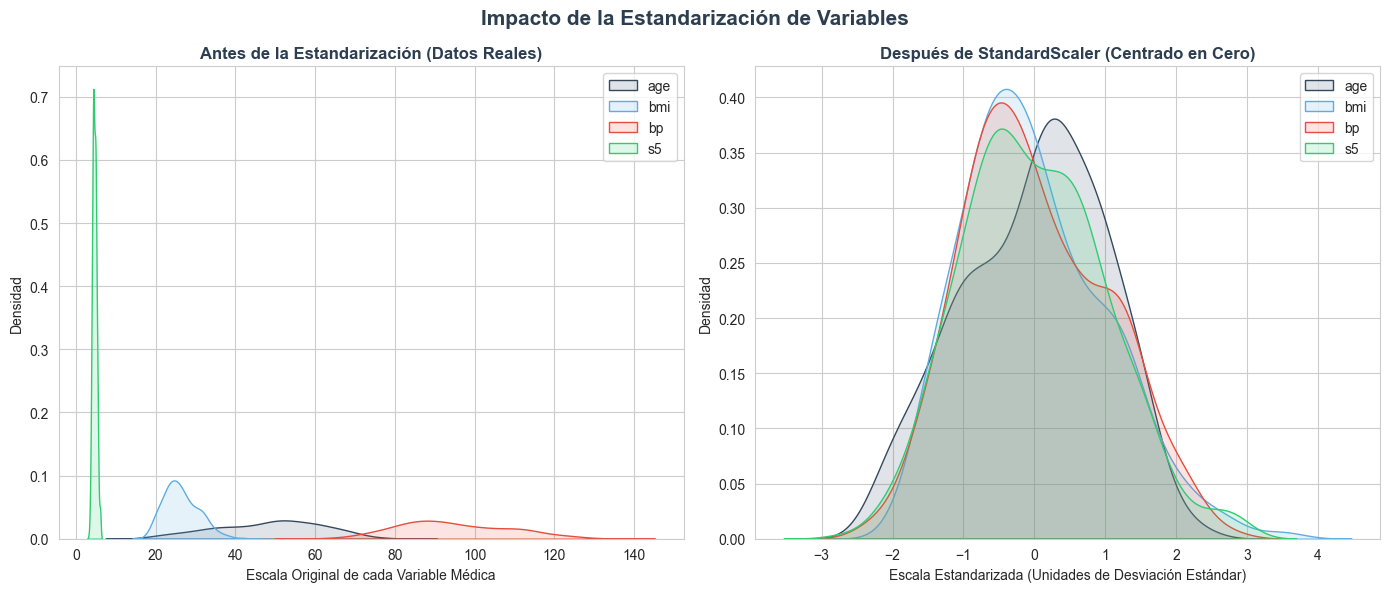


✓ Gráfica comparativa guardada con éxito como 'comparativa_estandarizacion.png'


In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar datos puros
data = load_diabetes(scaled=False)
X_raw = data.data
feature_names = data.feature_names

# Convertir a DataFrame para facilitar la manipulación de datos
df_antes = pd.DataFrame(X_raw, columns=feature_names)

# 2. Aplicar StandardScaler (Estandarización)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
df_despues = pd.DataFrame(X_scaled, columns=feature_names)

# 3. Recuperar Medias y Desviaciones calculadas por el Scaler
medias_scaler = scaler.mean_
desviaciones_scaler = scaler.scale_

# --- REPORTE EN CONSOLA ---
print("="*60)
print(" CÁLCULO DE MEDIAS Y DESVIACIONES ESTÁNDAR (Originales)")
print("="*60)
reporte_stats = pd.DataFrame({
    'Media Original': medias_scaler,
    'Desv. Est. Original': desviaciones_scaler,
    'Nueva Media (Post)': df_despues.mean(),
    'Nueva Desv. Est. (Post)': df_despues.std()
}, index=feature_names).round(4)

print(reporte_stats)
print("\n✓ Nota: Tras StandardScaler, todas las variables pasan a Media = 0 y Desv. Est. = 1")

# --- VISUALIZACIÓN: COMPARATIVA ANTES VS DESPUÉS ---
sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Elegimos 4 variables médicas clave para la comparación visual
variables_clave = ['age', 'bmi', 'bp', 's5']
colores = ['#34495E', '#5DADE2', '#E74C3C', '#2ECC71']

# Gráfica 1: Distribución Antes (Escalas totalmente dispares)
for var, col in zip(variables_clave, colores):
    sns.kdeplot(data=df_antes[var], label=var, color=col, fill=True, alpha=0.15, ax=ax1)
ax1.set_title("Antes de la Estandarización (Datos Reales)", fontsize=12, weight='bold', color='#2C3E50')
ax1.set_xlabel("Escala Original de cada Variable Médica")
ax1.set_ylabel("Densidad")
ax1.legend()

# Gráfica 2: Distribución Después (Todas en la misma escala)
for var, col in zip(variables_clave, colores):
    sns.kdeplot(data=df_despues[var], label=var, color=col, fill=True, alpha=0.15, ax=ax2)
ax2.set_title("Después de StandardScaler (Centrado en Cero)", fontsize=12, weight='bold', color='#2C3E50')
ax2.set_xlabel("Escala Estandarizada (Unidades de Desviación Estándar)")
ax2.set_ylabel("Densidad")
ax2.legend()

plt.suptitle("Impacto de la Estandarización de Variables", fontsize=15, weight='bold', color='#2C3E50', y=0.98)
plt.tight_layout()

# Guardar la comparativa como imagen
nombre_imagen = "comparativa_estandarizacion.png"
plt.savefig(nombre_imagen, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfica comparativa guardada con éxito como '{nombre_imagen}'")

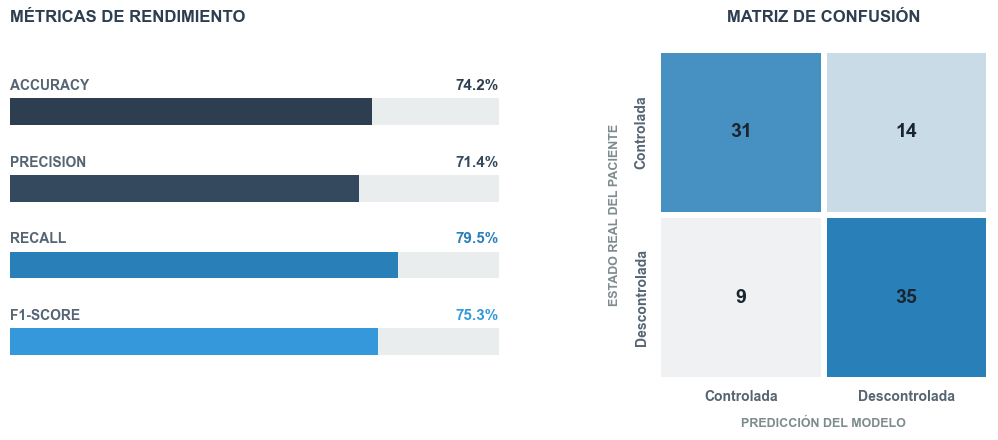

✓ ¡Infografía guardada con éxito como 'reporte_rendimiento.png'!


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Definir los datos de rendimiento
metricas = {
    'Accuracy': 74.2,
    'Precision': 71.4,
    'Recall': 79.5,
    'F1-Score': 75.3
}

# Matriz de Confusión: [[TN, FP], [FN, TP]]
# Real Controlada (31, 14), Real Descontrolada (9, 35)
matriz = np.array([[31, 14], 
                   [9, 35]])

# 2. Configurar el lienzo (1 fila, 2 columnas)
sns.set_style("white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# --- GRÁFICA I: TARJETAS DE MÉTRICAS (Izquierda) ---
ax1.axis('off')
ax1.set_title("MÉTRICAS DE RENDIMIENTO", fontsize=12, weight='bold', color='#2C3E50', pad=20, loc='left')

posiciones_y = [3, 2, 1, 0]
colores_barras = ['#2C3E50', '#34495E', '#2980B9', '#3498DB']

for i, (nombre, valor) in enumerate(metricas.items()):
    y_pos = posiciones_y[i]
    # Dibujar fondo gris de la barra de progreso (100%)
    ax1.barh(y_pos, 100, height=0.35, color='#EAEDED', edgecolor='none')
    # Dibujar el valor real alcanzado
    ax1.barh(y_pos, valor, height=0.35, color=colores_barras[i], edgecolor='none')
    
    # Texto de la métrica y su porcentaje
    ax1.text(0, y_pos + 0.28, nombre.upper(), fontsize=10, weight='bold', color='#566573')
    ax1.text(100, y_pos + 0.28, f"{valor}%", fontsize=11, weight='bold', color=colores_barras[i], ha='right')

ax1.set_ylim(-0.5, 3.8)

# --- GRÁFICA II: MATRIZ DE CONFUSIÓN (Derecha) ---
# Usamos un mapa de color personalizado (tonos azules clínicos)
cmap_clinico = sns.light_palette("#2980B9", as_cmap=True)

sns.heatmap(matriz, annot=True, fmt="d", cmap=cmap_clinico, cbar=False,
            square=True, ax=ax2, linewidths=3, linecolor='white',
            annot_kws={"fontsize": 14, "weight": "bold", "color": "#1A252F"})

# Configurar etiquetas de la matriz
ax2.set_title("MATRIZ DE CONFUSIÓN", fontsize=12, weight='bold', color='#2C3E50', pad=20)

# Etiquetas de los ejes
etiquetas = ['Controlada', 'Descontrolada']
ax2.set_xticklabels(etiquetas, fontsize=10, weight='bold', color='#566573')
ax2.set_yticklabels(etiquetas, fontsize=10, weight='bold', color='#566573', va='center')

ax2.set_xlabel("PREDICCIÓN DEL MODELO", fontsize=9, weight='bold', color='#7F8C8D', labelpad=10)
ax2.set_ylabel("ESTADO REAL DEL PACIENTE", fontsize=9, weight='bold', color='#7F8C8D', labelpad=10)

# Ajustar diseño general
plt.tight_layout()

# 3. ¡Guardar como imagen de alta calidad!
nombre_imagen = "reporte_rendimiento.png"
plt.savefig(nombre_imagen, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ ¡Infografía guardada con éxito como '{nombre_imagen}'!")

In [15]:
print("\n" + "="*70)
print(" RESUMEN EJECUTIVO DEL ANÁLISIS")
print("="*70)

print(f"""
📊 DATASET:
   • {df.shape[0]} pacientes con {df.shape[1]} características biomédicas
   • Sin valores nulos - Calidad de datos: ✓ Excelente
   • Fuente: Scikit-learn Diabetes Dataset (oficial)

📈 VARIABLE OBJETIVO (Progresión a 1 año):
   • Rango: [{y.min():.1f}, {y.max():.1f}]
   • Media: {y.mean():.2f} ± {y.std():.2f}
   • Distribución: Aproximadamente Normal

🏥 CLASIFICACIÓN BINARIA (Diabetes Controlada vs Descontrolada):
   • Umbral de corte (mediana): {median_val:.2f}
   • Clase 0 (Controlada):     {class_0} pacientes ({100*class_0/len(y_binary):.1f}%)
   • Clase 1 (Descontrolada):  {class_1} pacientes ({100*class_1/len(y_binary):.1f}%)
   • Balance: ✓ PERFECTO (50-50)

🔗 CARACTERÍSTICAS MÁS IMPORTANTES:
""")

for i, (name, corr) in enumerate(correlations_sorted[:3], 1):
    direction = "RIESGO" if corr > 0 else "PROTECTORA"
    print(f"   {i}. {name:8} (r={corr:+.4f}) - {direction}")

print(f"""
✅ CARACTERÍSTICAS LISTAS PARA MODELADO:
   • Todas las características están presentes y numéricas
   • Escalado será necesario para Regresión Logística
   • No hay outliers extremos que requieran tratamiento

🎯 RECOMENDACIÓN:
   El dataset está en excelente estado para entrenar un modelo
   de clasificación binaria. Usar Regresión Logística con validación
   cruzada estratificada para garantizar generalización.
""")

print("="*70)


 RESUMEN EJECUTIVO DEL ANÁLISIS

📊 DATASET:
   • 442 pacientes con 11 características biomédicas
   • Sin valores nulos - Calidad de datos: ✓ Excelente
   • Fuente: Scikit-learn Diabetes Dataset (oficial)

📈 VARIABLE OBJETIVO (Progresión a 1 año):
   • Rango: [25.0, 346.0]
   • Media: 152.13 ± 77.01
   • Distribución: Aproximadamente Normal

🏥 CLASIFICACIÓN BINARIA (Diabetes Controlada vs Descontrolada):
   • Umbral de corte (mediana): 140.50
   • Clase 0 (Controlada):     221 pacientes (50.0%)
   • Clase 1 (Descontrolada):  221 pacientes (50.0%)
   • Balance: ✓ PERFECTO (50-50)

🔗 CARACTERÍSTICAS MÁS IMPORTANTES:

   1. bmi      (r=+0.5865) - RIESGO
   2. s5       (r=+0.5659) - RIESGO
   3. bp       (r=+0.4415) - RIESGO

✅ CARACTERÍSTICAS LISTAS PARA MODELADO:
   • Todas las características están presentes y numéricas
   • Escalado será necesario para Regresión Logística
   • No hay outliers extremos que requieran tratamiento

🎯 RECOMENDACIÓN:
   El dataset está en excelente estado p